In [1]:
import pandas as pd
import glob

files = glob.glob(
    "../data/external/ki_endolist/**/*.csv",
    recursive=True
)

patient_files = [
    f for f in files
    if "User" in f and f.endswith(".csv")
]

dfs = []

for file in patient_files:
    df = pd.read_csv(file)
    dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

print(all_data.shape)

(5112, 387)


In [2]:
print(all_data.columns.tolist())

['User id', 'Day in study', 'Week day', 'Cycle number', 'Cycle day', 'First day of period', 'Period (0-no, 1-yes)', 'Migraines (0-no pain, 4-worst pain)', 'Period pain (0-no pain, 4-worst pain)', 'Type of stool (0-no stool, 7-bowel blockage)', 'General emotional condition (1-bad, 10-amazing)', 'General physical condition (1-bad, 10-amazing)', 'Breast tenderness (0-no pain, 4-worst pain)', 'Energy (0-no energy, 4-most energy)', 'Painful bowel movement (0-no pain, 4-worst pain)', 'Desire to eat sweet food (0-no appetite, 4-most appetite)', 'Lower back pain and pelvic pain (0-no pain, 4-worst pain)', 'Lower abdominal stabbing pain / abdominal cramps (0-no pain, 4-worst pain)', 'Ovulation pain (0-no pain, 4-worst pain)', 'Paracetamol (times)', 'Ovulation test values (0.0-4.0)', 'Knee pain (0-no pain, 4-worst pain)', 'Pain in ankle (0-no pain, 4-worst pain)', 'Sick day (0-no, 1-yes)', 'Naxyn (times)', 'Appetite (0-no appetite, 4-most appetite)', 'Headache (0-no pain, 10-worst pain)', 'Aller

In [3]:
for col in all_data.columns:
    if "pain" in col.lower():
        print(col)

Migraines (0-no pain, 4-worst pain)
Period pain (0-no pain, 4-worst pain)
Breast tenderness (0-no pain, 4-worst pain)
Painful bowel movement (0-no pain, 4-worst pain)
Lower back pain and pelvic pain (0-no pain, 4-worst pain)
Lower abdominal stabbing pain / abdominal cramps (0-no pain, 4-worst pain)
Ovulation pain (0-no pain, 4-worst pain)
Knee pain (0-no pain, 4-worst pain)
Pain in ankle (0-no pain, 4-worst pain)
Headache (0-no pain, 10-worst pain)
Morning pain (minutes)
Sinusitis (0-no pain, 10-worst pain)
Ovaries pain (0-no pain, 10-worst pain)
Lower back pain (0-no pain, 10-worst pain)
Lower back pain (0-no pain, 4-worst pain)
Pain in tailbone (0-no pain, 10-worst pain)
Breast tenderness (0-no pain, 10-worst pain)
Upper abdominal pain (0-no pain, 10-worst pain)
Lower abdominal pain (0-no pain, 10-worst pain)
Painful bowel movement (0-no pain, 10-worst pain)
Pain before bowel movement (0-no pain, 10-worst pain)
Sore feet (0-no pain, 10-worst pain)
Muscle pain / flu like (0-no pain, 4

In [4]:
for col in all_data.columns:
    if "fatigue" in col.lower():
        print(col)

Fatigue (0-no fatigue, 4-worst fatigue)
Fatigue (0-no fatigue, 10-worst fatigue)
Brain fatigue / brain fog (0-no fatigue, 4-worst fatigue)
Energy / fatigue (0-most fatigued, 10-most energetic)
Brain fatigue / brain fog (0-no fatigue, 10-worst fatigue)
Muscle weakness / fatigue (0-no fatigue, 10-worst fatigue)
Energy / fatigue (0-most fatigued, 4-most energetic)


In [5]:
targets = [
    "Period pain (0-no pain, 4-worst pain)",
    "Lower back pain (0-no pain, 4-worst pain)",
    "Abdominal cramps (0-no pain, 4-worst pain)",
    "Fatigue (0-no fatigue, 4-worst fatigue)",
    "Nausea (0-no nausea, 4-worst nausea)",
    "Headache (0-no pain, 4-worst pain)"
]

for col in targets:
    print(col)
    print(all_data[col].notna().sum())
    print()

Period pain (0-no pain, 4-worst pain)
1641

Lower back pain (0-no pain, 4-worst pain)
2075

Abdominal cramps (0-no pain, 4-worst pain)
1663

Fatigue (0-no fatigue, 4-worst fatigue)
1125

Nausea (0-no nausea, 4-worst nausea)
1681

Headache (0-no pain, 4-worst pain)
1879



In [6]:
print("User id" in all_data.columns)
print("Day in study" in all_data.columns)

True
True


In [8]:
forecast_df = all_data[
    [
        "User id",
        "Day in study",
        "Cycle day",
        "Period (0-no, 1-yes)",
        "Bleeding (0-no bleeding, 4-heaviest bleeding)",
        "General emotional condition (1-bad, 10-amazing)",
        "General physical condition (1-bad, 10-amazing)",
        "Lower back pain (0-no pain, 4-worst pain)"
    ]
].copy()

In [9]:
forecast_df.shape

(5112, 8)

In [10]:
forecast_df = forecast_df.sort_values(
    ["User id", "Day in study"]
)

In [11]:
forecast_df["Tomorrow_Lower_Back_Pain"] = (
    forecast_df
    .groupby("User id")
    ["Lower back pain (0-no pain, 4-worst pain)"]
    .shift(-1)
)

In [12]:
forecast_df = forecast_df.dropna()

print(forecast_df.shape)

(1111, 9)


In [13]:
X = forecast_df[
    [
        "Cycle day",
        "Period (0-no, 1-yes)",
        "Bleeding (0-no bleeding, 4-heaviest bleeding)",
        "General emotional condition (1-bad, 10-amazing)",
        "General physical condition (1-bad, 10-amazing)",
        "Lower back pain (0-no pain, 4-worst pain)"
    ]
]

y = forecast_df["Tomorrow_Lower_Back_Pain"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(888, 6)
(223, 6)


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [16]:
preds = rf.predict(X_test)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.6621942907615553
MSE: 0.7272577824792761
R2: 0.1766277601103745


In [18]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
5,"Lower back pain (0-no pain, 4-worst pain)",0.370771
0,Cycle day,0.284598
4,"General physical condition (1-bad, 10-amazing)",0.135480
3,"General emotional condition (1-bad, 10-amazing)",0.135003
2,"Bleeding (0-no bleeding, 4-heaviest bleeding)",0.058381
1,"Period (0-no, 1-yes)",0.015766


In [19]:
forecast_df["Pain_Lag_1"] = (
    forecast_df
    .groupby("User id")
    ["Lower back pain (0-no pain, 4-worst pain)"]
    .shift(1)
)

forecast_df["Pain_Lag_2"] = (
    forecast_df
    .groupby("User id")
    ["Lower back pain (0-no pain, 4-worst pain)"]
    .shift(2)
)

forecast_df["Pain_Lag_3"] = (
    forecast_df
    .groupby("User id")
    ["Lower back pain (0-no pain, 4-worst pain)"]
    .shift(3)
)

In [21]:
forecast_df["Pain_Rolling_3"] = (
    forecast_df
    .groupby("User id")
    ["Lower back pain (0-no pain, 4-worst pain)"]
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

In [23]:
forecast_v2 = forecast_df.dropna().copy()

print(forecast_v2.shape)

(1071, 13)


In [24]:
X = forecast_v2[
    [
        "Cycle day",
        "Period (0-no, 1-yes)",
        "Bleeding (0-no bleeding, 4-heaviest bleeding)",
        "General emotional condition (1-bad, 10-amazing)",
        "General physical condition (1-bad, 10-amazing)",
        "Lower back pain (0-no pain, 4-worst pain)",
        "Pain_Lag_1",
        "Pain_Lag_2",
        "Pain_Lag_3",
        "Pain_Rolling_3"
    ]
]

y = forecast_v2["Tomorrow_Lower_Back_Pain"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_v2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

preds = rf_v2.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 0.6263076411960133
MSE: 0.6077127417421061
R2: 0.3580548106254834


In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_v2.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
5,"Lower back pain (0-no pain, 4-worst pain)",0.295088
0,Cycle day,0.204824
9,Pain_Rolling_3,0.112660
4,"General physical condition (1-bad, 10-amazing)",0.097908
3,"General emotional condition (1-bad, 10-amazing)",0.088675
8,Pain_Lag_3,0.070179
6,Pain_Lag_1,0.041733
7,Pain_Lag_2,0.041564
2,"Bleeding (0-no bleeding, 4-heaviest bleeding)",0.039703
1,"Period (0-no, 1-yes)",0.007665


In [29]:
importance.to_csv(
    "../docs/forecast_feature_importance.csv",
    index=False
)

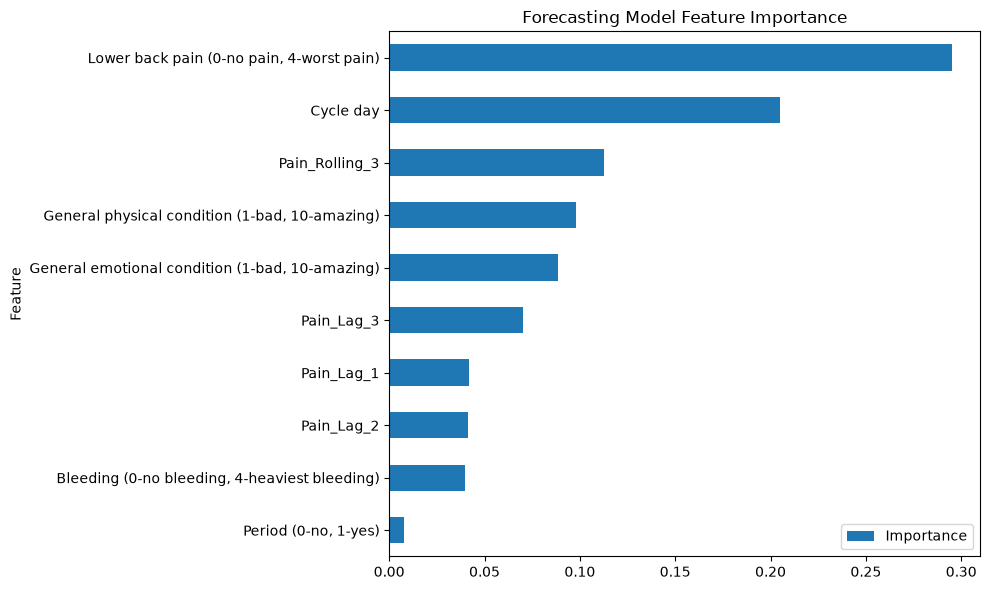

In [30]:
import matplotlib.pyplot as plt

importance.sort_values(
    "Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.title("Forecasting Model Feature Importance")
plt.tight_layout()

plt.savefig(
    "../docs/figures/forecast_feature_importance.png"
)

plt.show()